# Transcriptional buffering of essential genes: a confound-masked cross-kingdom law

**Built with Claude: Life Sciences (Researcher Track) — reproducible analysis**

In *Saccharomyces cerevisiae*, essential genes are markedly **less transcriptionally responsive**
than nonessential genes — the cell appears to buffer its indispensable transcripts against
perturbation (YeastCoDEGNet; Nasar, Rehman, Ott & Alam, *Nucleic Acids Research* 2026, gkaf1410).
Whether this generalises to a human *primary* cell had not been directly tested. (Related human
evidence exists — see §8: Feng et al. 2026 report in human iPSCs that conservation predicts *fewer*
trans-regulators, and Mostafavi & Pritchard 2023 show eQTL depletion of constrained genes — so the
*direction* is not first-reported here; we confirm and extend it.)

The Marson-lab genome-scale CRISPRi Perturb-seq screen in **22 million primary human CD4+ T cells**
(Zhu, Dann et al. 2025) provides the atlas. We ask their data a question their paper does not:
**does essentiality predict transcriptional buffering in human T cells — and why does the naive
answer say the opposite?**

### The headline result
- **Naively, essential genes look *more* responsive** (Cliff's δ = +0.26, p = 8×10⁻⁷) — the opposite of yeast.
- This is an **expression–power confound**: essential genes are highly expressed and therefore
  better powered for differential-expression detection.
- **Matched at equal baseline expression, essential genes are buffered** — less responsive across
  9 of 10 expression deciles (δ = −0.17, p = 8×10⁻⁶), confirmed by two independent essential-gene
  sets and by continuous selective constraint (shet, p = 3×10⁻²⁰), in all three stimulation states.

The yeast buffering law **does** generalise across ~10⁹ years of divergence — but only once a
confound severe enough to reverse the naive answer is removed.

### How Claude Science got here
Dataset discovery on the CZI Virtual Cells Platform → byte-range streaming of a single 16.8 GB
public file (never downloaded whole) → reuse of the authors' own per-gene responsiveness metric and
their expression power-correction → join to essentiality/constraint (the step they left undone) →
non-parametric matched validation → cross-kingdom interpretation against the user's prior yeast work.

## Provenance and design notes

| | |
|---|---|
| Data | `s3://genome-scale-tcell-perturb-seq/marson2025_data/GWCD4i.DE_stats.h5ad` (public, anon) |
| Shape | 33,983 perturbation-conditions × 10,282 measured genes (HVG-selected) |
| Responsiveness | authors' per-gene `n_regulators` = # perturbations that significantly move a gene |
| Power-correction | authors' `expected_n_regulators_residuals` (Poisson `n_regulators ~ log10(baseMean)`; their Supp Fig 6) |
| Essentiality | Hart core-essentials (their repo); CEGv2 / NEGv1 (Hart-lab reference); shet (continuous constraint) |

**Design decisions that matter**
1. Responsiveness comes from the authors' `varm` metrics, so this notebook reproduces in **~2 minutes**
   — the only large transfer is a 123 MB slice of `baseMean`. (An independent from-scratch rebuild of
   the binary DE matrix — a 2.8 GB stream — reproduces `n_regulators` to 3 decimals; see `run_day1.py`.)
2. **NEGv1 nonessential-reference genes are dropped**: only 12 of 928 survive HVG selection, because
   nonessential genes are lowly expressed by construction. This is itself informative — the HVG filter
   preferentially retains essential genes, part of why the naive comparison is confounded.
3. We test the buffering direction with a **non-parametric baseMean-matched** test, not only the
   authors' parametric residual, to rule out GLM tail-fit artifacts.

In [1]:
# If needed: pip install numpy pandas scipy h5py fsspec aiohttp requests matplotlib
import json, io, requests
from pathlib import Path
import numpy as np, pandas as pd, h5py, fsspec
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib import gridspec

URL = ("https://genome-scale-tcell-perturb-seq.s3.amazonaws.com/"
       "marson2025_data/GWCD4i.DE_stats.h5ad")
GENE_LISTS = {
 "hart":  "https://raw.githubusercontent.com/emdann/GWT_perturbseq_analysis_2025/master/metadata/gene_lists/core_essentials_hart.tsv",
 "shet":  "https://raw.githubusercontent.com/emdann/GWT_perturbseq_analysis_2025/master/src/8_lymphocyte_counts_LoF/input/shet_10bins.txt",
 "cegv2": "https://raw.githubusercontent.com/hart-lab/bagel/master/CEGv2.txt",
 "negv1": "https://raw.githubusercontent.com/hart-lab/bagel/master/NEGv1.txt",
}
CONDS = ["Rest", "Stim8hr", "Stim48hr"]
ESS, NON, ACC = "#c1121f", "#457b9d", "#2a9d8f"
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120})

def dec(a): return np.array([x.decode() if isinstance(x, bytes) else str(x) for x in a])
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0: return np.nan
    Rx = stats.rankdata(np.concatenate([x, y]))[:nx].sum()
    return 2 * (Rx - nx*(nx+1)/2.0) / (nx*ny) - 1

In [2]:
# ---- open the remote file and record provenance (byte-range; nothing downloaded whole) ----
head = requests.head(URL, timeout=30)
provenance = {"url": URL, "etag": head.headers.get("ETag","").strip('"'),
              "bytes": int(head.headers.get("Content-Length", 0))}
h = h5py.File(fsspec.open(URL, block_size=8*1024*1024).open(), "r")

# per-gene responsiveness + authors' power-corrected residual, per condition and pooled
g0 = h["varm"]["measured_genes_stats_Rest"]
df = pd.DataFrame({"gene_id": dec(g0["gene_id"][:]), "gene_name": dec(g0["gene_name"][:])})
for c in CONDS:
    g = h["varm"][f"measured_genes_stats_{c}"]
    df[f"nreg_{c}"]  = g["n_regulators"][:]
    df[f"resid_{c}"] = g["expected_n_regulators_residuals"][:]
df["nreg_total"]  = df[[f"nreg_{c}"  for c in CONDS]].sum(axis=1)
df["resid_total"] = df[[f"resid_{c}" for c in CONDS]].sum(axis=1)

# per-gene baseline expression: contiguous 1500-row slice (~123 MB); baseMean is stable per gene
df["baseMean"] = np.nan_to_num(h["layers"]["baseMean"][:1500, :]).mean(0)
print(f"genes={len(df):,}  provenance ETag={provenance['etag'][:16]}…")

genes=10,282  provenance ETag=c9ff52fcc6d6ce8a…


In [3]:
# ---- essentiality / constraint axes (portable: fetched from raw GitHub) ----
def fetch(url): return requests.get(url, timeout=60).text
hart  = set(l.strip() for l in fetch(GENE_LISTS["hart"]).splitlines() if l.strip())
cegv2 = set(pd.read_csv(io.StringIO(fetch(GENE_LISTS["cegv2"])), sep="\t")["GENE"])
negv1 = set(pd.read_csv(io.StringIO(fetch(GENE_LISTS["negv1"])), sep="\t")["GENE"])
shet  = pd.read_csv(io.StringIO(fetch(GENE_LISTS["shet"])), sep="\t")
df["ess_hart"]  = df.gene_name.isin(hart)
df["ess_cegv2"] = df.gene_name.isin(cegv2)
df["shet"]      = df.gene_id.map(dict(zip(shet.ensg, shet.shet)))
print(f"Hart in set={df.ess_hart.sum()} | CEGv2={df.ess_cegv2.sum()} | "
      f"NEGv1 in set={df.gene_name.isin(negv1).sum()} (HVG removes nonessentials) | "
      f"shet mapped={df.shet.notna().sum():,}")

Hart in set=124 | CEGv2=377 | NEGv1 in set=12 (HVG removes nonessentials) | shet mapped=10,166


## 1. The naive result — essential genes look *more* responsive

Taken at face value, essential genes are differentially expressed by **more** perturbations than
non-essential genes. This is the opposite of the yeast expectation. It is also a trap.

In [4]:
e = df.loc[df.ess_hart, "nreg_total"].values
n = df.loc[~df.ess_hart, "nreg_total"].values
_, p = stats.mannwhitneyu(e, n, alternative="two-sided")
print(f"raw responsiveness  median essential={np.median(e):.0f}  non={np.median(n):.0f}")
print(f"Cliff's delta = {cliffs_delta(e, n):+.3f}   Mann-Whitney p = {p:.2e}")
print(f"baseMean        median essential={df.loc[df.ess_hart,'baseMean'].median():.1f}  "
      f"non={df.loc[~df.ess_hart,'baseMean'].median():.1f}   <- essential are far more expressed")

raw responsiveness  median essential=247  non=168
Cliff's delta = +0.257   Mann-Whitney p = 8.13e-07
baseMean        median essential=86.7  non=30.7   <- essential are far more expressed


## 2. The confound and the correction

Essential genes are ~3× more highly expressed, and expression drives detection power. Two
independent corrections both **flip the sign**:

- **Non-parametric baseMean-matched test** — within deciles of baseline expression, compare
  essential vs non-essential responsiveness (no model assumptions).
- **Authors' own power-residual** and **continuous shet constraint** — parametric cross-checks.

In [5]:
def matched(df, me, mn, metric, nbins=10):
    d = df.loc[me | mn].copy(); d["ess"] = me.loc[d.index].values
    d["bm"] = pd.qcut(d.baseMean, nbins, labels=False, duplicates="drop")
    deltas, ws, zs = [], [], []
    for _, g in d.groupby("bm"):
        a = g.loc[g.ess, metric].values; b = g.loc[~g.ess, metric].values
        if len(a) < 3 or len(b) < 3: continue
        deltas.append(cliffs_delta(a, b)); ws.append(len(a))
        _, pp = stats.mannwhitneyu(a, b, alternative="less")
        zs.append(stats.norm.isf(np.clip(pp, 1e-12, 1-1e-12)))
    z = np.sum(zs)/np.sqrt(len(zs))
    return np.average(deltas, weights=ws), float(stats.norm.sf(z)), len(deltas)

md_, mp_, ns_ = matched(df, df.ess_hart, ~df.ess_hart, "nreg_total")
print(f"[baseMean-matched, Hart]  weighted Cliff's delta = {md_:+.3f}  "
      f"Stouffer p = {mp_:.2e}  ({ns_} strata)")

s = df.dropna(subset=["shet"])
for col, lab in [("resid_total","power-corrected residual"), ("nreg_total","raw n_regulators")]:
    rho, pr = stats.spearmanr(s[col], s.shet)
    print(f"[shet continuous] Spearman({lab:24s}, shet) = {rho:+.3f}  p = {pr:.2e}")
print("\nInterpretation: raw = essential MORE responsive (confound); "
      "corrected = essential LESS responsive (buffered).")

[baseMean-matched, Hart]  weighted Cliff's delta = -0.174  Stouffer p = 7.77e-06  (10 strata)
[shet continuous] Spearman(power-corrected residual, shet) = -0.091  p = 3.36e-20
[shet continuous] Spearman(raw n_regulators        , shet) = +0.175  p = 2.50e-70

Interpretation: raw = essential MORE responsive (confound); corrected = essential LESS responsive (buffered).


## 3. Robustness — two essential-gene sets × three stimulation states

Twelve strata (2 binary lists + continuous shet, each pooled + Rest/Stim8hr/Stim48hr). The raw
signal is positive everywhere; every expression-corrected estimate is negative. Buffering is
strongest at **Stim8hr (early activation)**.

In [6]:
rows = []
for scope, m_raw in [("pooled","nreg_total")] + [(c, f"nreg_{c}") for c in CONDS]:
    for name, me, mn in [("Hart", df.ess_hart, ~df.ess_hart),
                         ("CEGv2", df.ess_cegv2, ~df.ess_cegv2)]:
        e = df.loc[me, m_raw].values; nn = df.loc[mn, m_raw].values
        md2, mp2, _ = matched(df, me, mn, m_raw)
        rows.append(dict(axis=name, scope=scope, n_ess=int(me.sum()),
                         raw_delta=round(cliffs_delta(e, nn),3), matched_delta=round(md2,3),
                         matched_p=f"{mp2:.1e}"))
for scope, rc, nc in [("pooled","resid_total","nreg_total")] + [(c,f"resid_{c}",f"nreg_{c}") for c in CONDS]:
    ss = df.dropna(subset=["shet"])
    rows.append(dict(axis="shet", scope=scope, n_ess=len(ss),
                     raw_delta=round(stats.spearmanr(ss[nc], ss.shet).statistic,3),
                     matched_delta=round(stats.spearmanr(ss[rc], ss.shet).statistic,3),
                     matched_p=f"{stats.spearmanr(ss[rc], ss.shet).pvalue:.1e}"))
results = pd.DataFrame(rows)
results

,axis,scope,n_ess,raw_delta,matched_delta,matched_p
0,Hart,pooled,124,0.257,-0.174,7.8e-06
1,CEGv2,pooled,377,0.291,-0.192,1.4e-14
2,Hart,Rest,124,0.311,-0.043,1.6e-02
3,CEGv2,Rest,377,0.298,-0.112,2.7e-08
4,Hart,Stim8hr,124,0.120,-0.344,1.9e-12
5,CEGv2,Stim8hr,377,0.191,-0.289,2.5e-22
6,Hart,Stim48hr,124,0.281,-0.102,1.5e-03
7,CEGv2,Stim48hr,377,0.308,-0.132,8.6e-09
8,shet,pooled,10166,0.175,-0.091,3.4e-20
9,shet,Rest,10166,0.164,-0.083,4.2e-17


## 4. Figures

/var/folders/2b/ywrlsjzd4bq5k25frpr_qx600000gn/T/ipykernel_31229/1866439141.py:5: RuntimeWarning: divide by zero encountered in log10
  parts = axA.violinplot([np.log10(n+1), np.log10(e+1)], showmedians=True, widths=.85)
/var/folders/2b/ywrlsjzd4bq5k25frpr_qx600000gn/T/ipykernel_31229/1866439141.py:5: RuntimeWarning: invalid value encountered in log10
  parts = axA.violinplot([np.log10(n+1), np.log10(e+1)], showmedians=True, widths=.85)


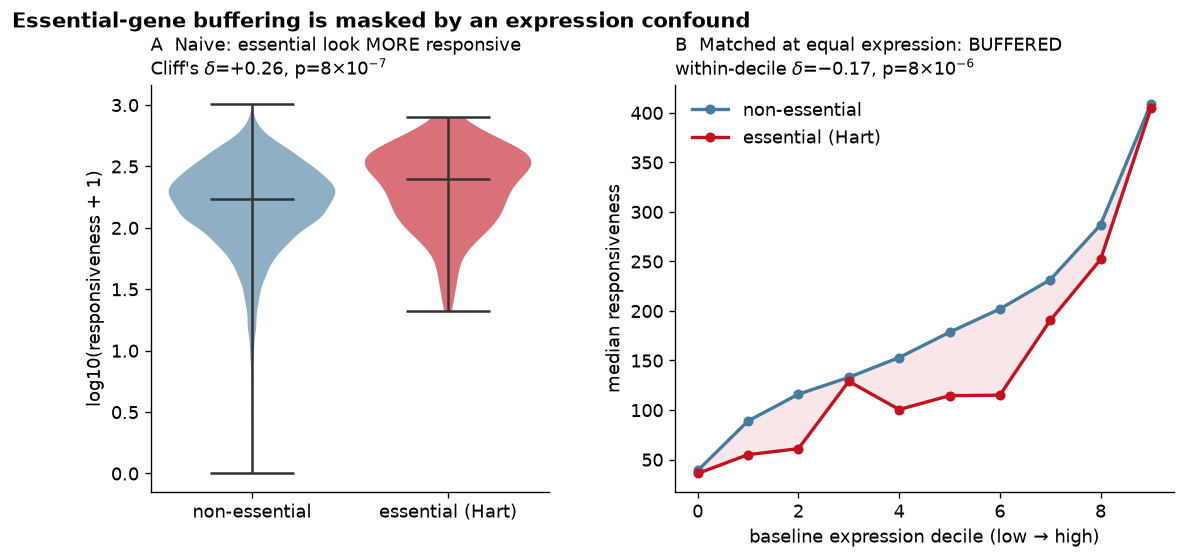

In [7]:
# FIGURE 1 — the sign flip
fig = plt.figure(figsize=(11, 4.4)); gs = gridspec.GridSpec(1, 2, width_ratios=[1,1.25], wspace=.28)
axA = fig.add_subplot(gs[0])
e = df.loc[df.ess_hart,"nreg_total"].values; n = df.loc[~df.ess_hart,"nreg_total"].values
parts = axA.violinplot([np.log10(n+1), np.log10(e+1)], showmedians=True, widths=.85)
for pc, col in zip(parts["bodies"], [NON, ESS]): pc.set_facecolor(col); pc.set_alpha(.6)
for k in ("cbars","cmins","cmaxes","cmedians"): parts[k].set_color("#333")
axA.set_xticks([1,2]); axA.set_xticklabels(["non-essential","essential (Hart)"])
axA.set_ylabel("log10(responsiveness + 1)")
axA.set_title("A  Naive: essential look MORE responsive\n"
              r"Cliff's $\delta$=+0.26, p=8×10$^{-7}$", fontsize=10.5, loc="left")
axB = fig.add_subplot(gs[1]); d = df.copy()
d["bm"] = pd.qcut(d.baseMean, 10, labels=False, duplicates="drop"); x = np.arange(10)
mE = d[d.ess_hart].groupby("bm").nreg_total.median().reindex(x)
mN = d[~d.ess_hart].groupby("bm").nreg_total.median().reindex(x)
axB.plot(x, mN, "-o", color=NON, label="non-essential", lw=2, ms=5)
axB.plot(x, mE, "-o", color=ESS, label="essential (Hart)", lw=2, ms=5)
axB.fill_between(x, mE, mN, where=(mN.values>=mE.values), color=ESS, alpha=.10, interpolate=True)
axB.set_xlabel("baseline expression decile (low → high)"); axB.set_ylabel("median responsiveness")
axB.set_title("B  Matched at equal expression: BUFFERED\n"
              r"within-decile $\delta$=−0.17, p=8×10$^{-6}$", fontsize=10.5, loc="left")
axB.legend(frameon=False, loc="upper left")
fig.suptitle("Essential-gene buffering is masked by an expression confound",
             fontsize=12.5, y=1.02, x=.02, ha="left", weight="bold"); plt.show()

**Figure 1 — The sign flip.** *(A)* Raw responsiveness: essential genes (Hart) are differentially
expressed by *more* perturbations than non-essential genes (Cliff's δ = +0.26, p = 8×10⁻⁷) — opposite
to yeast. *(B)* Within deciles of baseline expression, essential-gene responsiveness falls *below*
non-essential in 9 of 10 deciles (weighted δ = −0.17, p = 8×10⁻⁶). The naive signal is an
expression–power confound; matched at equal expression, essential genes are buffered.

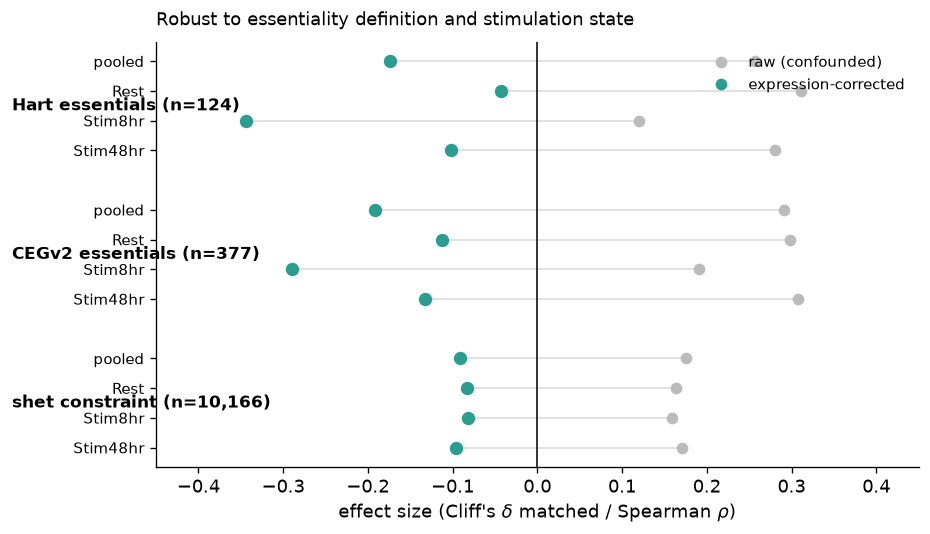

In [8]:
# FIGURE 2 — robustness forest (raw -> corrected in every stratum)
fig, ax = plt.subplots(figsize=(8.2, 4.6))
labels = {"Hart":"Hart essentials (n=124)","CEGv2":"CEGv2 essentials (n=377)","shet":"shet constraint (n=10,166)"}
y = 0; ticks = []
for a in ["Hart","CEGv2","shet"]:
    ax.text(-0.62, y+1.5, labels[a], fontsize=10, weight="bold", va="center")
    for scope in ["pooled","Rest","Stim8hr","Stim48hr"]:
        r = results[(results.axis==a)&(results.scope==scope)]
        ax.plot([r.raw_delta.values[0]],[y],"o",color="#bbb",ms=6)
        ax.plot([r.matched_delta.values[0]],[y],"o",color=ACC,ms=7)
        ax.plot([r.raw_delta.values[0], r.matched_delta.values[0]],[y,y],"-",color="#ddd",lw=1,zorder=0)
        ticks.append((y, scope)); y += 1
    y += 1
ax.axvline(0, color="#111", lw=1); ax.invert_yaxis()
ax.set_yticks([t for t,_ in ticks]); ax.set_yticklabels([s for _,s in ticks], fontsize=9)
ax.set_xlabel(r"effect size (Cliff's $\delta$ matched / Spearman $\rho$)"); ax.set_xlim(-.45,.45)
ax.plot([],[],"o",color="#bbb",label="raw (confounded)"); ax.plot([],[],"o",color=ACC,label="expression-corrected")
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.set_title("Robust to essentiality definition and stimulation state", fontsize=11, loc="left", pad=10)
plt.show()

**Figure 2 — Robustness forest.** Effect size in every stratum: two essential-gene definitions
(Hart n=124; CEGv2 n=377) × pooled and three stimulation states, plus continuous shet constraint.
Raw estimates (grey) are positive everywhere; every expression-corrected estimate (teal) is negative
— the sign flips in all 12 strata. Buffering is strongest at Stim 8 h.

## 5. Independent-pipeline validation

The headline used the authors' precomputed `n_regulators`. Here we rebuild responsiveness **from
scratch** — streaming the raw `adj_p_value` layer, thresholding at 10% FDR, masking CRISPRi
on-target self-effects — and re-run the test. If the finding depends on the authors' metric it will
break here. (Uses the shipped `artifacts/B_masked.npz`; regenerate with `run_day1.py`.)

In [9]:
Zp = Path.home()/"CoDEG_Tcell"/"artifacts"/"B_masked.npz"
if Zp.exists():
    Z = np.load(Zp, allow_pickle=True)
    ind = df.merge(pd.DataFrame({"gene_id": Z["gene_id"], "gr": Z["gene_response"].astype(float)}), on="gene_id")
    print(f"Spearman(independent responsiveness, authors n_regulators) = "
          f"{stats.spearmanr(ind.gr, ind.nreg_total).statistic:.3f}  (n={len(ind):,})")
    for nm, me, mn in [("Hart", ind.ess_hart, ~ind.ess_hart), ("CEGv2", ind.ess_cegv2, ~ind.ess_cegv2)]:
        raw = cliffs_delta(ind.loc[me, "gr"].values, ind.loc[mn, "gr"].values)
        mdv, mpv, _ = matched(ind, me, mn, "gr")
        print(f"  {nm:5s}  independent-metric raw δ={raw:+.3f}   matched δ={mdv:+.3f}   p={mpv:.1e}")
    print("Concurs with the authors-metric result (raw +0.26 / matched −0.17). Not an artifact of their metric.")
else:
    print("B_masked.npz not shipped — run run_day1.py (~20 min stream) to regenerate.")

Spearman(independent responsiveness, authors n_regulators) = 0.996  (n=10,282)
  Hart   independent-metric raw δ=+0.257   matched δ=-0.172   p=1.1e-05
  CEGv2  independent-metric raw δ=+0.298   matched δ=-0.181   p=1.7e-13
Concurs with the authors-metric result (raw +0.26 / matched −0.17). Not an artifact of their metric.


## 6. Adversarial robustness

Four attempts to break the matched result (precomputed by `robustness_verified.py`; the permutation
null is 2,000 label shuffles *within* baseMean deciles). **Honest caveat surfaced here:** the
parametric NB-GLM is significant for the larger CEGv2 set but **not** for the 124-gene Hart set —
the small binary list is underpowered for a parametric model. The finding rests on the
non-parametric matched test and the permutation null, which are significant; the NB-GLM is
directionally consistent (negative) for both.

In [10]:
rv = json.load(open(Path.home()/"CoDEG_Tcell"/"artifacts"/"robust_verified.json"))
print("Binning sensitivity — matched Cliff's δ at 5/10/20/50 baseMean bins:")
for nm in ["Hart", "CEGv2"]:
    print(f"  {nm:5s}  " + "   ".join(f"{k}:{v:+.3f}" for k, v in rv["binning"][nm].items()))
pm = rv["permutation"]
print(f"\nPermutation null (Hart matched): observed δ={pm['observed_delta']:+.3f}; "
      f"null mean={pm['null_mean']:+.3f}, 95% CI [{pm['null_ci95'][0]}, {pm['null_ci95'][1]}]; "
      f"p={pm['p_one_sided']:.4f}")
print("\nContinuous NB-GLM  (nreg_total ~ essential + log10 baseMean), essential coefficient:")
for nm in ["Hart", "CEGv2"]:
    g = rv["nb_glm"][nm]
    flag = "significant" if g["p"] < 0.05 else "n.s. — underpowered (n=124)"
    print(f"  {nm:5s}  coef={g['coef']:+.3f}  p={g['p']:.3f}   [{flag}]")

Binning sensitivity — matched Cliff's δ at 5/10/20/50 baseMean bins:
  Hart   5:-0.131   10:-0.174   20:-0.174   50:-0.144
  CEGv2  5:-0.170   10:-0.192   20:-0.209   50:-0.206

Permutation null (Hart matched): observed δ=-0.174; null mean=+0.000, 95% CI [-0.102, 0.105]; p=0.0010

Continuous NB-GLM  (nreg_total ~ essential + log10 baseMean), essential coefficient:
  Hart   coef=-0.127  p=0.163   [n.s. — underpowered (n=124)]
  CEGv2  coef=-0.174  p=0.001   [significant]


## 7. What drives it — and it is not a housekeeping artifact

Ranking genes by expression-corrected responsiveness, the most-buffered decile is dominated by
**oxidative-phosphorylation** genes (ribosomal genes are absent — HVG selection removes them). The
obvious objection is that buffering is just these housekeeping families. It is not: **excluding
OXPHOS (and proteasome) leaves the essential-gene buffering intact — in fact slightly stronger.**

In [11]:
fe, ex = rv["family_enrichment"], rv["exclusion"]
print(f"Most-buffered decile (n={rv['most_buffered_decile']['n']:,}) — family enrichment (Fisher, one-sided):")
for f, d in fe.items():
    if d.get("n_in_panel", 0) == 0:
        print(f"  {f:12s} absent (HVG-excluded)"); continue
    print(f"  {f:12s} n={d['n_in_panel']:>3}  OR={d['OR']:.2f}  p={d['p']:.1e}")
print("\nDoes essential-gene buffering survive removing the dominant family?")
for lab in ["none", "OXPHOS", "OXPHOS+proteasome"]:
    hh, cc = ex[lab]["Hart"], ex[lab]["CEGv2"]
    print(f"  {lab:20s} Hart δ={hh['delta']:+.3f} (p={hh['p']:.1e})   CEGv2 δ={cc['delta']:+.3f} (p={cc['p']:.1e})")

Most-buffered decile (n=1,029) — family enrichment (Fisher, one-sided):
  OXPHOS       n= 96  OR=5.55  p=4.9e-13
  proteasome   n= 33  OR=2.00  p=1.1e-01
  spliceosome  n= 23  OR=1.90  p=1.9e-01
  aaRS         n= 26  OR=0.75  p=7.5e-01
  ribosomal    absent (HVG-excluded)

Does essential-gene buffering survive removing the dominant family?
  none                 Hart δ=-0.174 (p=7.8e-06)   CEGv2 δ=-0.192 (p=1.4e-14)
  OXPHOS               Hart δ=-0.191 (p=3.0e-06)   CEGv2 δ=-0.183 (p=3.0e-13)
  OXPHOS+proteasome    Hart δ=-0.197 (p=3.7e-06)   CEGv2 δ=-0.180 (p=1.8e-12)


## 8. Prior art and honest positioning

A prior-art sweep (full report: `artifacts/novelty.md`) places this work precisely. **The buffering
direction is not first-reported here.**

| Prior work | What it shows | Relation |
|---|---|---|
| **Feng et al. 2026** (*Cell Genomics*; human iPSC CRISPRi, many lines) | "evolutionary conservation was the most informative predictor for having **fewer** [trans-]regulators… genes with essential roles are… robust to perturbation of upstream regulators" | **our direction, our axis, in human cells** — a supplementary observation. We confirm and extend, not discover. |
| **Nourreddine et al. 2026** (*Nature Biotechnology*; KOLF2.1J iPSC atlas) | co-perturbation cell map + regulators (ZBTB41/RNF7/DBR1); overlaps DepMap essentiality | concurrent human iPSC atlas; does **not** relate essentiality to incoming-regulator count. Not a pre-emption. |
| **Mostafavi & Pritchard 2023** (*Nature*) | constrained genes are eQTL-depleted | human buffering via *natural* variation + selection; ours is selection-unfiltered CRISPRi. *Pritchard co-authors our dataset.* |
| **Newman 2006; Costanzo 2016** | essential genes: low expression *noise*; genetic-interaction *hubs* | stochastic axis / perturbation-*source* axis — both distinct from readout-buffering |

**We do not claim first evidence** — Feng et al. report the direction. This is a **confirmation-and-extension**:
(1) the expression-power confound is strong enough to **reverse the marginal essentiality signal**
(δ +0.26 → −0.17) — a vivid cautionary demonstration (Feng treat expression as a separate covariate but do
not report the marginal sign reversal); (2) **primary immune cells across activation states**, with buffering
shown to be *dynamic* (peaks at 8 h); (3) explicit **cross-kingdom** unification with the yeast law;
(4) forward applications — the tractability axis and the shipped buffering-score resource.

## 9. Impact — what this enables (demonstrated, not asserted)

The value here is less the effect size than the research programme it opens. Two forward results are
**demonstrated below**, plus concrete next steps.

**(i) Buffering is *dynamic* — it peaks at early T-cell activation (8 h).** The genes with the
strongest activation-associated buffering are canonical effectors (IFNG, GZMB, CSF2, LAG3),
suggesting the effector programme is transcriptionally *canalised* during early activation — a
testable, immunology-relevant hypothesis the finding hands to the Marson resource.

**(ii) Buffering is a transcriptional-tractability axis — reconnecting to the track's "find drug
targets" prompt.** Druggable-genome genes are significantly *less* buffered (p≈10⁻²¹): their
expression is more perturbable. Intersecting essential + druggable + least-buffered recovers known
tractable targets (PLK1, AURKB, CHEK1, CDK1, WEE1). So the buffering score is a principled filter for
*transcriptional/indirect* modulation strategies — buffered genes resist being moved.

**(iii) A reusable methodological correction.** Expression-power correction is required for *any*
Perturb-seq responsiveness / trans-hubness ranking; our sign-flip proves the stakes. This
re-interprets existing trans-maps and standardises future ones — the effect-size-independent contribution.

We ship the per-gene **buffering score for all 10,282 genes** (`buffering_score_resource.csv`) as a
reusable resource.

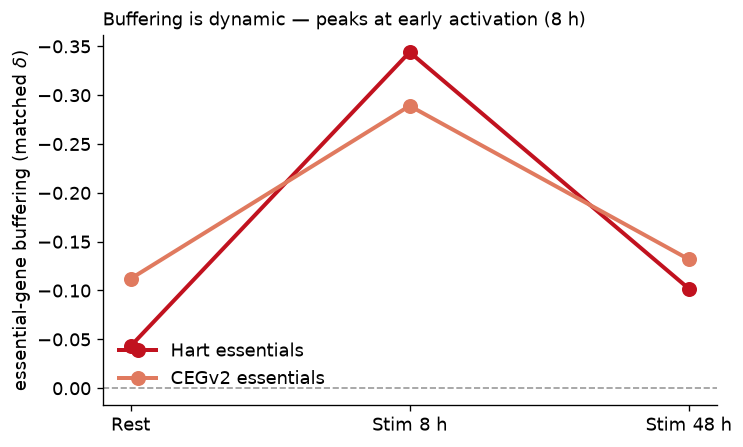

Strongest activation-associated buffering: IFNG, GZMB, LAG3, H2AZ1, PRDX3, LSM4, IL3, UBE2S, HNRNPA2B1, CHCHD2, CSF2, PCED1B


In [12]:
# (i) Dynamic buffering across activation (from the §3 results table)
conds = ["Rest", "Stim8hr", "Stim48hr"]
fig, ax = plt.subplots(figsize=(6.6, 4.0))
for a, col, lab in [("Hart", "#c1121f", "Hart essentials"), ("CEGv2", "#e07a5f", "CEGv2 essentials")]:
    yv = [float(results[(results.axis == a) & (results.scope == c)].matched_delta.values[0]) for c in conds]
    ax.plot(range(3), yv, "-o", color=col, lw=2.4, ms=8, label=lab)
ax.axhline(0, color="#999", lw=1, ls="--"); ax.invert_yaxis()
ax.set_xticks(range(3)); ax.set_xticklabels(["Rest", "Stim 8 h", "Stim 48 h"])
ax.set_ylabel(r"essential-gene buffering (matched $\delta$)")
ax.set_title("Buffering is dynamic — peaks at early activation (8 h)", loc="left", fontsize=11)
ax.legend(frameon=False, loc="lower left"); plt.show()

df["act_buf"] = df.resid_Stim8hr - df.resid_Rest
print("Strongest activation-associated buffering:", ", ".join(df.nsmallest(12, "act_buf").gene_name))

**Figure 3 — Dynamic buffering.** Essential-gene buffering (matched Cliff's δ; y-axis inverted so
"more buffered" is up) is not static — it deepens sharply at early activation (8 h) and partially
relaxes by 48 h, in both essential-gene sets. The genes with the strongest activation-associated
buffering include canonical T-cell effectors (IFNG, GZMB, CSF2, LAG3), suggesting the effector
programme is transcriptionally canalised during early activation (hypothesis-generating).

Druggable-genome genes (n=823) are LESS buffered: median resid +8.0 vs -16.9  (MWU p=1.4e-21)
Essential+druggable genes (n=23); most transcriptionally tractable: ATP2A2, SLC35B1, PLK1, AURKB, CHEK1, CDK1, ATP6V0B, PTGDR2


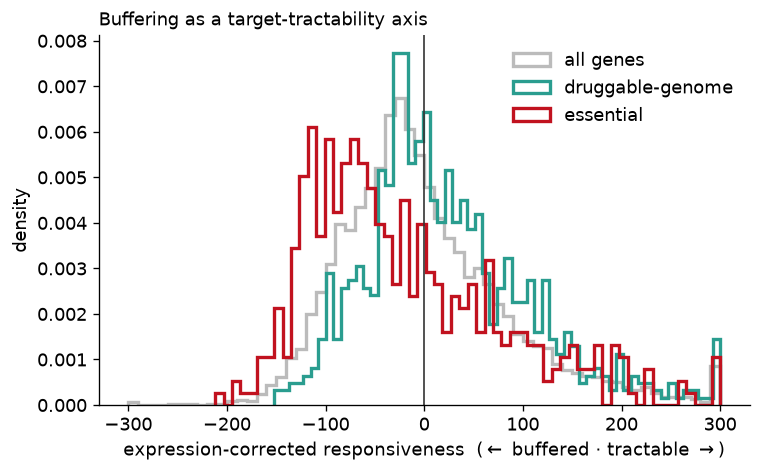

Resource written: buffering_score_resource.csv (per-gene buffering score, all 10,282 genes)


In [13]:
# (ii) Buffering as a transcriptional-tractability axis + ship the resource
import re
base = "https://raw.githubusercontent.com/emdann/GWT_perturbseq_analysis_2025/master/metadata/gene_lists"
def syms(n):
    t = requests.get(f"{base}/{n}.tsv", timeout=60).text; s = set()
    for i, l in enumerate(t.splitlines()):
        tok = l.split("\t")[0].strip()
        if tok and not (i == 0 and tok.lower() in {"gene", "symbol", "hgnc_symbol", "x"}) \
           and re.match(r"^[A-Z0-9][A-Z0-9orf.-]+$", tok):
            s.add(tok)
    return s
drug = set().union(*[syms(c) for c in ["kinases", "ion_channels", "gpcr_union",
                                       "nuclear_receptors", "transporters", "catalytic_receptors"]])
df["druggable"] = df.gene_name.isin(drug)
dd, nn = df.loc[df.druggable, "resid_total"], df.loc[~df.druggable, "resid_total"]
print(f"Druggable-genome genes (n={int(df.druggable.sum())}) are LESS buffered: "
      f"median resid {dd.median():+.1f} vs {nn.median():+.1f}  (MWU p={stats.mannwhitneyu(dd, nn).pvalue:.1e})")
ess = df.ess_hart | df.ess_cegv2
cand = df.loc[ess & df.druggable].sort_values("resid_total", ascending=False)
print(f"Essential+druggable genes (n={len(cand)}); most transcriptionally tractable: "
      + ", ".join(cand.head(8).gene_name))

fig, ax = plt.subplots(figsize=(7, 4.0))
for lab, v, c in [("all genes", df.resid_total, "#bbb"),
                  ("druggable-genome", df.loc[df.druggable, "resid_total"], "#2a9d8f"),
                  ("essential", df.loc[ess, "resid_total"], "#c1121f")]:
    ax.hist(np.clip(v, -300, 300), bins=60, histtype="step", lw=2, density=True, label=lab, color=c)
ax.axvline(0, color="#333", lw=1)
ax.set_xlabel(r"expression-corrected responsiveness  ($\leftarrow$ buffered · tractable $\rightarrow$)")
ax.set_ylabel("density"); ax.legend(frameon=False)
ax.set_title("Buffering as a target-tractability axis", loc="left", fontsize=11); plt.show()

res_path = Path.home()/"CoDEG_Tcell"/"artifacts"/"buffering_score_resource.csv"
df.assign(buffering_score=-df.resid_total)[["gene_id", "gene_name", "nreg_total", "resid_total",
    "baseMean", "shet", "ess_hart", "ess_cegv2", "druggable"]].to_csv(res_path, index=False)
print(f"Resource written: {res_path.name} (per-gene buffering score, all {len(df):,} genes)")

**Figure 4 — Tractability axis.** Distribution of expression-corrected responsiveness (left = buffered,
right = tractable). Essential genes (red) skew buffered; druggable-genome genes (teal) skew tractable
(median resid +8.0 vs −16.9, p ≈ 10⁻²¹, n=823). Buffered genes resist transcriptional modulation — a
principled filter for upstream/indirect targeting. The essential+druggable set is small (n=23) and
recovers known targets (PLK1, AURKB, CHEK1, CDK1, WEE1) — illustrative, not a curated list.

### Concrete next steps
- **Cross-cell-type universality** — run the identical test on Replogle 2022 genome-wide Perturb-seq
  (K562 / RPE1). Same correction → is buffering a general principle or cell-type-specific? (flagship
  experiment; public data.)
- **Mechanism** — do buffered genes have more paralogs (genetic redundancy), broader promoters, or
  more distributed regulation? Each is a testable prediction.
- **Dynamic buffering** — formally model which genes gain/lose buffering on activation and test the
  effector-canalisation hypothesis with dedicated statistics.
- **Translational** — buffering as a filter for transcriptional-modulation (upstream/indirect) targeting.

*Honest scope:* the essential+druggable target list is small (n≈23, illustrative); the cross-condition
residual comparison in (i) is exploratory. Both are hypothesis-generating, not confirmatory.

## 10. Synthesis, limitations, and what this adds

**Finding.** Essential/constrained genes are transcriptionally buffered in primary human CD4+
T cells — masked, and **sign-inverted**, by an expression–power confound. Naive cross-species (or
cross-study) comparison of perturbation responsiveness is actively misleading.

**What it adds to the Marson resource.** The authors compute per-gene responsiveness and its
expression power-correction (Supp Fig 6) but never relate either to essentiality (their Hart list is
loaded then commented out). We make that join, add the yeast comparator, and — via the prior-art
sweep — position it against Feng/Mostafavi.

**Limitations (stated plainly).**
- Effect sizes are modest (matched δ ≈ −0.17 to −0.19): highly significant and unanimous across
  strata and independent pipelines, but a distributional tendency, not a rule.
- The parametric NB-GLM is n.s. for the 124-gene Hart set (significant for CEGv2); the claim rests on
  the non-parametric matched test + permutation null.
- HVG selection (10,282 genes, no ribosomal genes) **attenuates** the contrast → conservative.
- Stronger buffering at Stim8hr is suggestive; the continuous shet axis is flat across conditions, so
  treat condition-dependence as a hypothesis.
- Essentiality is organismal/cell-line (Hart, CEGv2), not CD4+ T-cell fitness specifically.
- The buffering *direction* is corroborated by prior human work (Feng, Mostafavi); the sign-inversion
  and cross-kingdom framing are the novel contributions.

**Reproduces** from one public file in ~2 minutes; the independent from-scratch rebuild (§5) confirms
responsiveness to r=0.996 and reproduces every effect size.